In [1]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [2]:
#Load the dataset
import pandas as pd

pd.ExcelFile('/content/heart_disease.xlsx').sheet_names

['Description', 'Heart_disease']

In [3]:
df = pd.read_excel(
    '/content/heart_disease.xlsx',
    sheet_name='Heart_disease',

)

In [6]:
print(df.head())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  


#### Exploratory Data analysis

In [7]:
#check missing values
print("\nMissing values in each column:")
print(df_num.isnull().sum())



Missing values in each column:
age          0
trestbps     0
chol         0
thalch       0
oldpeak     62
num          0
dtype: int64


In [8]:
#summary
print("\nStatistical summary:")
print(df_num.describe())



Statistical summary:
              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


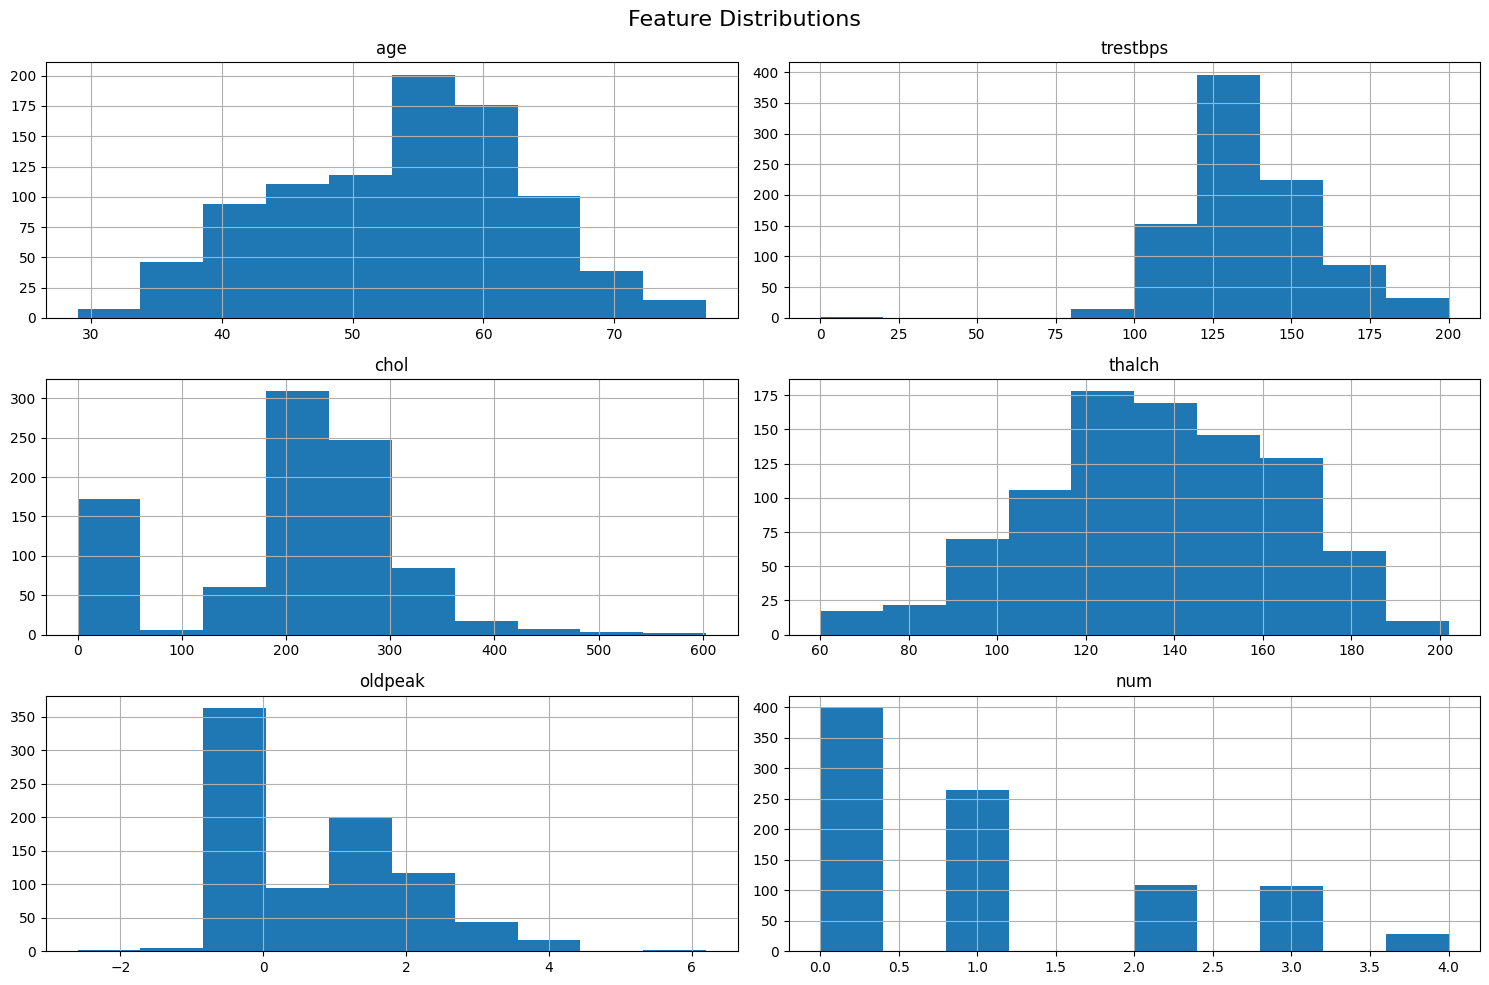

In [9]:
#Histograms
df_num.hist(figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


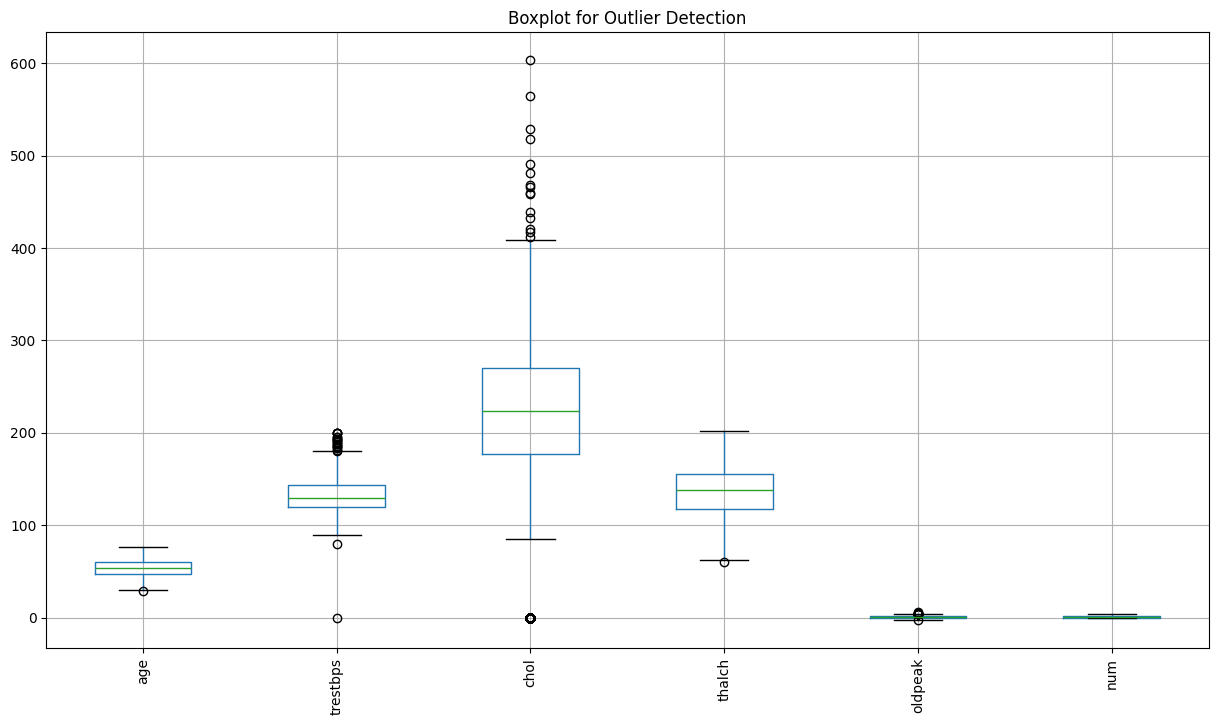

In [10]:
#Boxplot
plt.figure(figsize=(15,8))
df_num.boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()


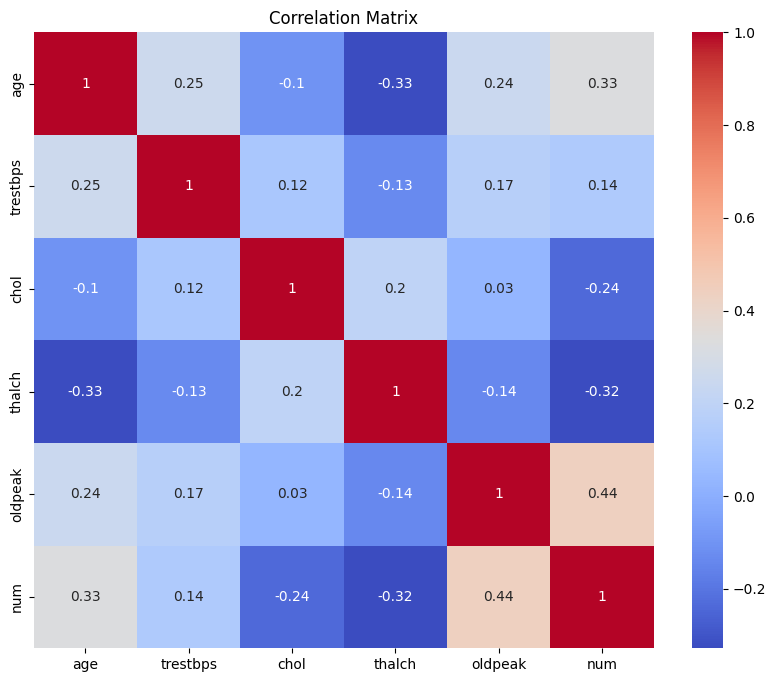

In [11]:
#Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


#### Feature Engeneering

In [14]:
# Handle Missing Values
df_num = df_num.fillna(df_num.median())

print("\nMissing values handled using median imputation")
print(df_num.median())



Missing values handled using median imputation
age          54.0
trestbps    130.0
chol        224.0
thalch      138.0
oldpeak       0.5
num           1.0
dtype: float64


In [19]:
#Split Feature and Target
X = df_num.drop("num", axis=1)
y = df_num["num"]

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)



Feature matrix shape: (908, 5)
Target vector shape: (908,)


In [20]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData split completed")
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Data split completed
Training set size: (726, 5)
Testing set size: (182, 5)


In [21]:
#Decision tree model(baseline)
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("\nDecision Tree model trained successfully")



Decision Tree model trained successfully


#### model evaluation

In [23]:
#Predictions
y_pred = dt.predict(X_test)

print("\nPredictions generated successfully!")
print("Number of predictions:", len(y_pred))
print(" predicted values:")
print(y_pred[::-1])



Predictions generated successfully!
Number of predictions: 182
 predicted values:
[1 3 1 0 1 2 2 0 2 0 1 3 0 4 1 0 1 0 1 0 2 0 0 0 0 3 1 2 2 0 0 3 0 2 0 0 2
 2 1 0 0 0 3 2 0 0 1 0 2 0 0 2 1 1 1 1 1 0 1 0 1 3 1 2 1 1 3 0 3 3 3 1 2 2
 1 1 1 0 1 2 2 1 0 1 0 1 0 1 0 1 3 1 2 1 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 4 3
 0 0 1 0 3 1 1 4 0 0 0 1 0 0 1 1 0 0 0 0 2 1 0 0 0 0 0 0 0 1 3 1 0 0 1 0 0
 1 1 1 4 0 0 0 0 3 0 1 1 0 1 4 0 0 0 2 3 1 0 0 3 0 0 0 2 2 0 0 1 1 3]


In [24]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)



Accuracy: 0.4340659340659341


In [25]:
#Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.51      0.54        89
           1       0.35      0.44      0.39        48
           2       0.36      0.36      0.36        22
           3       0.28      0.29      0.29        17
           4       0.00      0.00      0.00         6

    accuracy                           0.43       182
   macro avg       0.32      0.32      0.32       182
weighted avg       0.45      0.43      0.44       182



In [26]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[45 33  4  5  2]
 [15 21  6  3  3]
 [ 7  3  8  4  0]
 [ 8  2  2  5  0]
 [ 2  1  2  1  0]]


In [28]:
# roc-auc score
y_prob = dt.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("\nROC-AUC Score (One-vs-Rest):", roc_auc)



ROC-AUC Score (One-vs-Rest): 0.5850861163391256


In [29]:
#Hyperparameter Tuning
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("\nBest Hyperparameters:")
print(grid.best_params_)



Best Hyperparameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}


In [30]:
#train optimized model
best_dt = grid.best_estimator_
best_dt.fit(X_train, y_train)

y_pred_best = best_dt.predict(X_test)

print("\nOptimized Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_best))



Optimized Decision Tree Accuracy: 0.5659340659340659


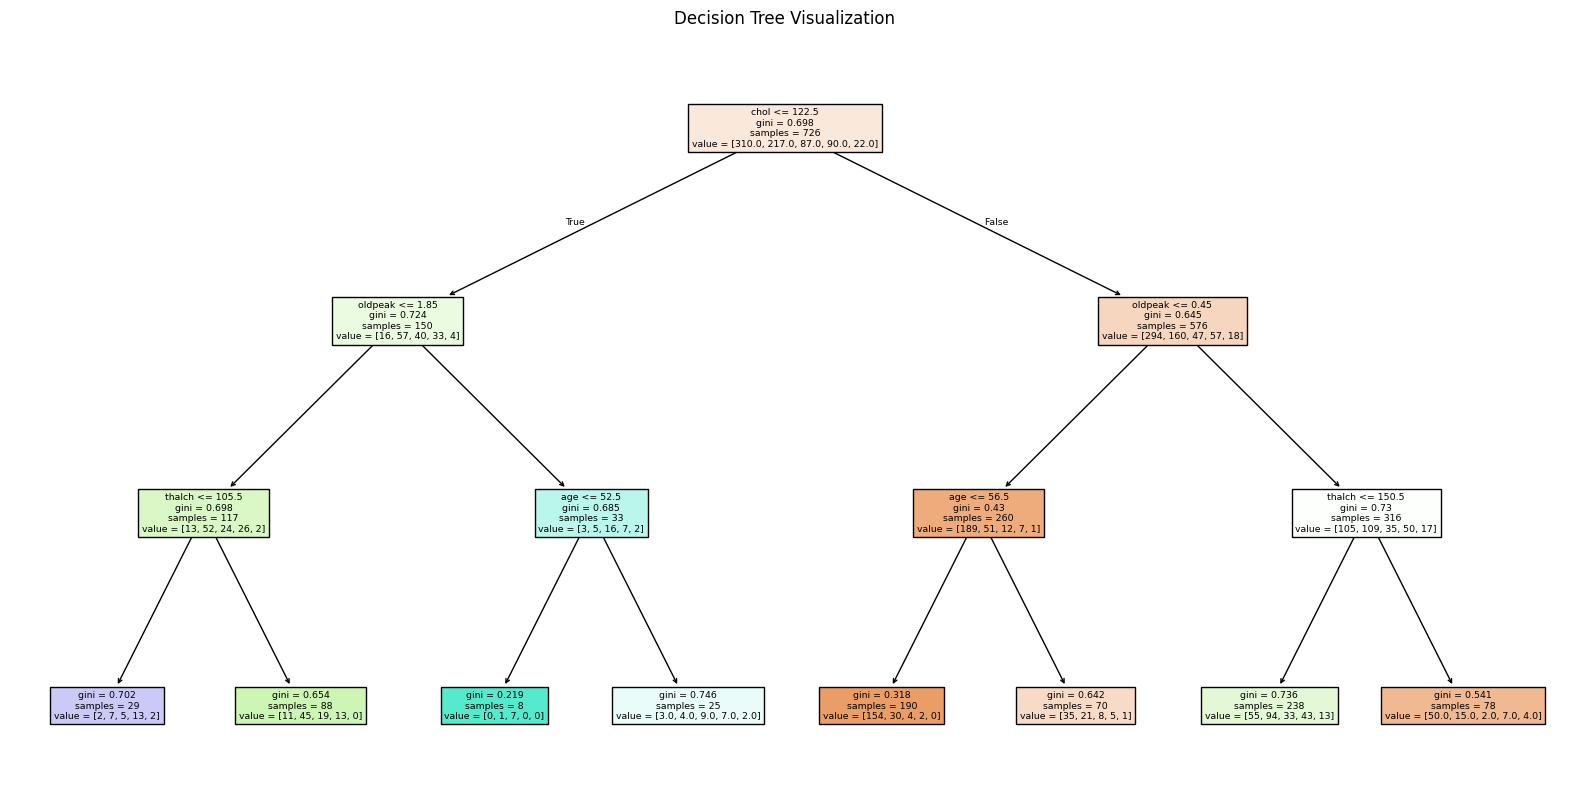

In [32]:
#Visualize decision tree
plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


####Interview questions

In [ ]:
# Common Hyperparameters of Decision Tree:

#max_depth: Controls tree depth; prevents overfitting

#min_samples_split: Minimum samples required to split a node

#min_samples_leaf: Minimum samples required at a leaf node

#criterion: Metric to measure split quality (gini or entropy)

#max_features: Number of features considered for splitting

#Proper tuning avoids overfitting and improves generalization.

In [ ]:
#| Label Encoding                 | One-Hot Encoding           |
#| ------------------------------ | -------------------------- |
#| Converts categories to numbers | Creates binary columns     |
#| Example: Red=0, Blue=1         | Red → [1,0], Blue → [0,1]  |
#| Suitable for tree models       | Suitable for linear models |
#| Can introduce false order      | No ordinal relationship    |
# Decision Trees handle label encoding well, but since your assignment uses numerical data only, encoding was not required.